In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
import seaborn as sns

In [2]:
# BOOK_FIGURE_STYLE_CELL
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

try:
    import seaborn as sns
except ImportError:
    sns = None

try:
    import matplotlib_inline

    matplotlib_inline.backend_inline.set_matplotlib_formats("svg")
except Exception:
    matplotlib_inline = None

FIGURE_SIZES = {
    "full_landscape": (7.35, 4.40),
    "full_standard": (7.35, 4.90),
    "full_tall": (7.35, 5.50),
    "half_standard": (3.55, 2.55),
    "half_tall": (3.55, 3.05),
    "inset": (2.30, 1.75),
}

BOOK_COLORS = {
    "blue": "#4C78A8",
    "orange": "#F58518",
    "green": "#54A24B",
    "red": "#E45756",
    "gray": "#7F7F7F",
}

BOOK_TARGET = "web"


def setup_book_style(target="web"):
    global BOOK_TARGET
    BOOK_TARGET = target
    mpl.rcParams.update(
        {
            "figure.figsize": FIGURE_SIZES["half_standard"],
            "figure.dpi": 120,
            "savefig.dpi": 300,
            "savefig.bbox": "tight",
            "savefig.pad_inches": 0.02,
            "font.family": "sans-serif",
            "font.sans-serif": ["DejaVu Sans", "Arial", "Liberation Sans"],
            "axes.labelsize": 9,
            "axes.titlesize": 9,
            "axes.linewidth": 0.8,
            "axes.grid": False,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "xtick.labelsize": 8,
            "ytick.labelsize": 8,
            "xtick.major.width": 0.8,
            "ytick.major.width": 0.8,
            "legend.fontsize": 8,
            "legend.frameon": False,
            "lines.linewidth": 1.5,
            "lines.markersize": 4,
            "patch.linewidth": 0.8,
            "image.cmap": "viridis",
        }
    )
    if target == "latex":
        try:
            mpl.rcParams["text.usetex"] = False
        except Exception:
            mpl.rcParams["text.usetex"] = False


def new_figure(
    size="half_standard",
    nrows=1,
    ncols=1,
    sharex=False,
    sharey=False,
    constrained=True,
    squeeze=True,
    **kwargs,
):
    fig, ax = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        sharex=sharex,
        sharey=sharey,
        constrained_layout=constrained,
        figsize=FIGURE_SIZES[size],
        squeeze=squeeze,
        **kwargs,
    )
    return fig, ax


def label_panels(axes=None, labels=None, x=0.02, y=0.98, **kwargs):
    if axes is None:
        axes = plt.gcf().axes
    axes = np.atleast_1d(axes).ravel()
    if labels is None:
        labels = [f"({chr(97 + i)})" for i in range(len(axes))]
    default = dict(
        fontsize=9,
        fontweight="semibold",
        va="top",
        ha="left",
        transform=None,
    )
    default.update(kwargs)
    for ax, label in zip(axes, labels):
        call_kwargs = dict(default)
        if call_kwargs["transform"] is None:
            call_kwargs["transform"] = ax.transAxes
        ax.text(x, y, label, **call_kwargs)


def finalize_axes(axes=None, keep_box=False, grid=False):
    if axes is None:
        axes = plt.gcf().axes
    axes = np.atleast_1d(axes).ravel()
    for ax in axes:
        if grid:
            ax.grid(axis="y", color="0.88", linewidth=0.6)
        else:
            ax.grid(False)
        for spine in ax.spines.values():
            spine.set_linewidth(0.8)
        if keep_box:
            ax.spines["top"].set_visible(True)
            ax.spines["right"].set_visible(True)
        else:
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
    return axes


def save_book_figure(fig, basename, target="web", pdf=True, png=False):
    base = Path(basename)
    base.parent.mkdir(parents=True, exist_ok=True)
    if pdf:
        fig.savefig(base.with_suffix(".pdf"), bbox_inches="tight", pad_inches=0.02)
    if png:
        fig.savefig(base.with_suffix(".png"), bbox_inches="tight", pad_inches=0.02)


setup_book_style(target="web")


# Optimization Algorithms with Adaptive Learning Rates


Gradient descent uses one learning rate to scale every component of the gradient. When the gradient components have very different scales, a single rate can make some parameters move too slowly while others oscillate. Adaptive methods address this problem by giving each parameter a scale computed from its gradient history.

## The delta-bar-delta rule

{cite:t}`jacobs1988increased` introduced the "delta-bar-delta" rule, an early adaptive learning-rate algorithm.
The rule maintains a separate learning rate for each parameter. If a component of the gradient keeps the same sign on consecutive steps, its rate increases; if the sign changes, its rate decreases. A persistent sign suggests that the parameter can move faster, whereas repeated sign changes suggest oscillation. This coordinatewise adaptation motivates the methods that follow.



## Adaptive gradient algorithm (AdaGrad)

The AdaGrad algorithm was introduced by {cite:t}`duchi2011adaptive`.
Let $n$ be the number of parameters and let $f:\mathbb{R}^n\to\mathbb{R}$ be a differentiable objective. At step $t\geq 1$, let $x_{t-1}\in\mathbb{R}^n$ be the current parameter vector and let $g_t=\nabla f(x_{t-1})\in\mathbb{R}^n$ be its gradient. The vector $r_t\in\mathbb{R}^n$ stores one nonnegative scale for each parameter. Let $\alpha>0$ be the base learning rate and let $\epsilon>0$ be a small constant that prevents division by zero. Squares, square roots, divisions, and additions of $\epsilon$ involving vectors below are all performed componentwise.

Starting from an initial parameter vector $x_0$ and the zero vector $r_0=0$, AdaGrad applies

$$
g_t = \nabla f(x_{t-1}), \qquad
r_t = r_{t-1}+g_t^2, \qquad
x_t = x_{t-1}-\frac{\alpha}{\sqrt{r_t+\epsilon}}g_t.
$$

For any coordinate $i\in\{1,\ldots,n\}$, the $i$th parameter has the effective learning rate $\alpha/\sqrt{r_{t,i}+\epsilon}$. A history of large values of the gradient component $g_{t,i}$ makes this rate decrease quickly, whereas a history of small values makes it decrease slowly.

AdaGrad's effective learning rates decrease monotonically. On long optimization runs they can become so small that progress stalls, which motivates the moving-average construction used by RMSProp.


## Root mean square propagation (RMSProp)

{cite:t}`hinton2012rmsprop` presented RMSProp in course lectures rather than in a journal paper.
RMSProp prevents the scale from growing indefinitely by replacing AdaGrad's cumulative sum with an exponentially weighted moving average. Using the notation above, choose a decay factor $\beta\in[0,1)$ and initialize $r_0=0$. RMSProp applies

$$
g_t = \nabla f(x_{t-1}), \qquad
r_t = \beta r_{t-1}+(1-\beta)g_t^2, \qquad
x_t = x_{t-1}-\frac{\alpha}{\sqrt{r_t+\epsilon}}g_t.
$$

The factor $\beta$ controls how slowly the algorithm forgets old squared gradients. Because old values lose weight, the effective learning rates need not decrease monotonically.

## Adaptive moment estimation (Adam)

The Adam algorithm was introduced by {cite:t}`kingma2015adam`.
Adam combines the moving average of gradients used by momentum with the moving average of squared gradients used by RMSProp. Choose decay factors $\beta_1,\beta_2\in[0,1)$, and initialize the gradient-average accumulator $m_0$ and squared-gradient-average accumulator $v_0$ as zero vectors in $\mathbb{R}^n$. The bias-corrected accumulators are denoted by $\hat{m}_t$ and $\hat{v}_t$. Adam applies

$$
\begin{aligned} g_t &= \nabla f(x_{t-1}), \\ m_t &= \beta_1m_{t-1}+(1-\beta_1)g_t, \\ v_t &= \beta_2v_{t-1}+(1-\beta_2)g_t^2, \\ \hat{m}_t &= \frac{m_t}{1-\beta_1^t}, \qquad \hat{v}_t = \frac{v_t}{1-\beta_2^t}, \\ x_t &= x_{t-1}-\frac{\alpha}{\sqrt{\hat{v}_t}+\epsilon}\hat{m}_t. \end{aligned}
$$

Zero initialization makes the two moving averages too small during the first few steps. The factors $1-\beta_1^t$ and $1-\beta_2^t$ remove this initialization bias. For example, at the first step,

$$
m_1=(1-\beta_1)g_1, \qquad \hat{m}_1=\frac{m_1}{1-\beta_1}=g_1.
$$

Common starting values are $\beta_1=0.9$, $\beta_2=0.999$, and $\epsilon=10^{-8}$, while the base learning rate $\alpha$ remains a problem-dependent choice.

Consider again the quadratic regression model from stochastic gradient descent, written here as $h(z;\theta)=\theta_0+\theta_1z+\theta_2z^2$ because $x$ denotes the parameter vector in this section. Here $z\in\mathbb{R}$ is the input and $\theta=(\theta_0,\theta_1,\theta_2)\in\mathbb{R}^3$ is the coefficient vector. The example generates data with coefficient vector $\theta=(0,-2,1.5)$ and estimates it with the Optax implementation of Adam. For both the training and test sets, the reported loss is the average of $\frac{1}{2}(h(z;\theta)-y)^2$ over the observed input-response pairs $(z,y)$.

In [3]:
import jax.numpy as jnp
import jax.random as jrandom

key = jrandom.key(0)

# Generate some synthetic data
N = 1_000
key, x_key, train_noise_key, test_noise_key = jrandom.split(key, 4)
X = jrandom.normal(x_key, (N,))
y = 1.5 * X ** 2 - 2 * X + jrandom.normal(train_noise_key, (N,)) * 0.5

# Generate a test set on an evenly spaced grid
N_test = 50
X_test = jnp.linspace(-3, 3, N_test)
y_test = 1.5 * X_test ** 2 - 2 * X_test + jrandom.normal(test_noise_key, (N_test,)) * 0.5

import numpy as np
import equinox as eqx
import jax
import optax
from functools import partial


class MyModel(eqx.Module):
    theta: jax.Array

    def __init__(self, key):
        self.theta = jax.random.normal(key, (3,))
    
    @partial(jax.vmap, in_axes=(None, 0))
    def __call__(self, x):
        return self.theta @ jnp.array([1, x, x ** 2])
    
# Generate one randomly shuffled pass through the data
def data_generator(x, y, batch_size, key):
    num_samples = x.shape[0]
    indices = jrandom.permutation(key, num_samples)
    
    for start_idx in range(0, num_samples, batch_size):
        end_idx = min(start_idx + batch_size, num_samples)
        batch_indices = indices[start_idx:end_idx]
        yield x[batch_indices], y[batch_indices]

# This is the training loop
def train_batch(
        model,
        x, y,
        optimizer,
        x_test, y_test,
        key,
        batch_size=10,
        n_epochs=10,
        record_every=10,
    ):
    
    # This is the loss function
    @eqx.filter_jit
    def loss(model, x, y):
        y_pred = model(x)
        return optax.l2_loss(y_pred, y).mean()

    # This is one compiled optimizer step
    @eqx.filter_jit
    def step(opt_state, model, xi, yi):
        value, grads = eqx.filter_value_and_grad(loss)(model, xi, yi)
        updates, opt_state = optimizer.update(grads, opt_state, params=model)
        model = eqx.apply_updates(model, updates)
        return model, opt_state, value
    
    opt_state = optimizer.init(model)
    path = []
    steps = []
    train_losses = []
    test_losses = []
    update_step = 0
    for _ in range(n_epochs):
        key, epoch_key = jrandom.split(key)
        for xb, yb in data_generator(x, y, batch_size, epoch_key):
            model, opt_state, _ = step(opt_state, model, xb, yb)
            update_step += 1
            if update_step % record_every == 0:
                path.append(model)
                steps.append(update_step)
                train_losses.append(loss(model, x, y))
                test_losses.append(loss(model, x_test, y_test))
    return model, path, steps, train_losses, test_losses

In [4]:
key, model_key, shuffle_key = jrandom.split(key, 3)

model = MyModel(model_key)

optimizer = optax.adam(0.01, b1=0.9, b2=0.999, eps=1e-8)

model, path, steps, train_losses, test_losses = train_batch(
    model,
    X, y,
    optimizer,
    X_test, y_test,
    key=shuffle_key,
    batch_size=10,
    n_epochs=20,
    record_every=10,
)

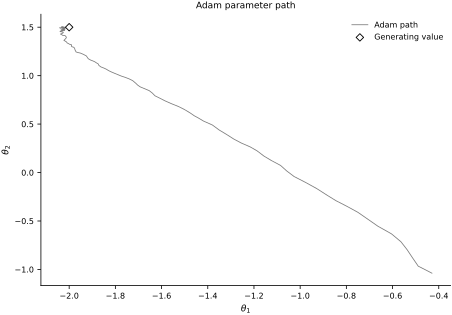

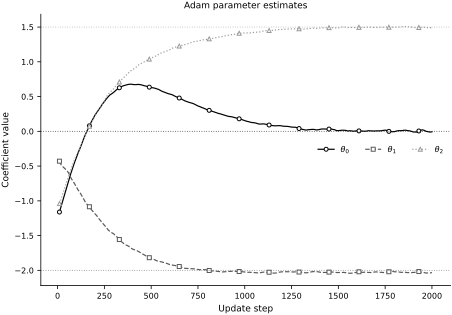

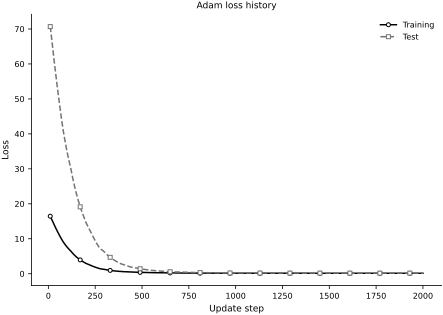

In [5]:
thetas = np.stack([model.theta for model in path])
true_theta = np.array([0.0, -2.0, 1.5])

# Path of the two nonconstant coefficients
fig, ax = plt.subplots(figsize=FIGURE_SIZES["full_standard"])
ax.plot(thetas[:, 1], thetas[:, 2], color="0.2", alpha=0.65, lw=0.8, label="Adam path")
ax.scatter(
    [true_theta[1]], [true_theta[2]], marker="D", s=28,
    facecolor="white", edgecolor="black", linewidth=0.9,
    label="Generating value", zorder=3,
)
ax.set(xlabel=r"$\theta_1$", ylabel=r"$\theta_2$", title="Adam parameter path")
ax.legend(loc="best")
finalize_axes(keep_box=False)

# Parameter estimates by optimizer update
fig, ax = plt.subplots(figsize=FIGURE_SIZES["full_standard"])
line_styles = ["-", "--", ":"]
markers = ["o", "s", "^"]
gray_levels = ["0.0", "0.35", "0.60"]
mark_every = max(1, len(steps) // 12)
for i, (line_style, marker, gray) in enumerate(
    zip(line_styles, markers, gray_levels)
):
    ax.plot(
        steps, thetas[:, i], color=gray, linestyle=line_style,
        marker=marker, markevery=mark_every, markerfacecolor="white",
        markeredgecolor=gray, linewidth=1.2, label=rf"$\theta_{i}$",
    )
    ax.axhline(
        true_theta[i], color=gray, linestyle=(0, (1, 2)),
        linewidth=0.8, alpha=0.8,
    )
ax.set(xlabel="Update step", ylabel="Coefficient value", title="Adam parameter estimates")
ax.legend(loc="best", ncol=3)
finalize_axes(keep_box=False)

# Training and test losses
fig, ax = plt.subplots(figsize=FIGURE_SIZES["full_standard"])
ax.plot(
    steps, train_losses, color="black", linestyle="-",
    marker="o", markevery=mark_every, markerfacecolor="white",
    label="Training",
)
ax.plot(
    steps, test_losses, color="0.45", linestyle="--",
    marker="s", markevery=mark_every, markerfacecolor="white",
    label="Test",
)
ax.set(xlabel="Update step", ylabel="Loss", title="Adam loss history")
ax.legend(loc="best")
finalize_axes(keep_box=False);

The estimated coefficients approach the generating values, while both the training and test losses decrease. Adam is a useful baseline, although it is not universally best and its hyperparameters may still require tuning. Its coordinatewise scaling also does not replace a schedule for the base learning rate $\alpha$; changing or reducing $\alpha$ during training may still improve convergence.